# Tutorial 1c: Materials, Catalogs and Databases

Consolidating basic material queries, built-in catalogs, material registries, search policies, and custom glass definitions.


### January 2025

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.materials import AbbeMaterial, AbbeMaterialE, IdealMaterial, Material

## 1. Ideal Material

The `IdealMaterial` class represents a material with a fixed refractive index and extinction coefficient. This is useful for simulations that require simple, constant parameters.

In [2]:
ideal_material = IdealMaterial(n=1.5, k=0)

wavelengths = [0.48, 0.55, 0.65]

for wavelength in wavelengths:
    print(f"Refractive Index at {wavelength} µm: {ideal_material.n(wavelength)}")
    print(
        f"Extinction Coefficient at {wavelength} µm: {ideal_material.k(wavelength)}",
        end="\n\n",
    )

Refractive Index at 0.48 µm: 1.5
Extinction Coefficient at 0.48 µm: 0.0

Refractive Index at 0.55 µm: 1.5
Extinction Coefficient at 0.55 µm: 0.0

Refractive Index at 0.65 µm: 1.5
Extinction Coefficient at 0.65 µm: 0.0



## 2. Abbe Material

The `AbbeMaterial` class generates a model optical glass material in the visible spectrum. The material is defined by its refractive index at a reference wavelength and its Abbe number. Optiland supports two distinct definitions:

1.  **Standard d-line ($V_d$)**:
    * **Reference ($n_d$):** Helium d-line at **587.56 nm**.
    * **Abbe Number ($V_d$):** Calculated using Hydrogen F (486.1 nm) and C (656.3 nm) lines.
    * *Models:* "buchdahl" (Recommended) and "polynomial" (Legacy).

2.  **e-line ($V_e$)**:
    * **Reference ($n_e$):** Mercury e-line at **546.07 nm**.
    * **Abbe Number ($V_e$):** Calculated using Cadmium F' (**480.0 nm**) and C' (**643.8 nm**) lines.
    * *Model:* `AbbeMaterialE` class.

The extinction coefficient is set to zero for these models but can be overwritten manually.

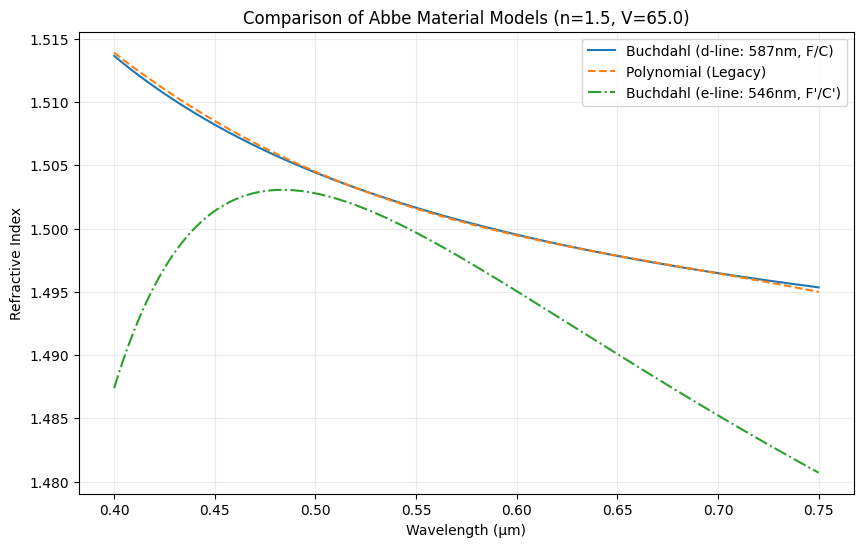

In [3]:
# Create instances of the different Abbe models

# 1. Buchdahl Model (d-line) - The new recommended default
# Input: Index at 587.56 nm, Abbe number Vd (using F/C lines)
abbe_buchdahl = AbbeMaterial(n=1.5, abbe=65.0, model="buchdahl")

# 2. Legacy Polynomial Model (d-line)
# Input: Index at 587.56 nm, Abbe number Vd (using F/C lines)
abbe_poly = AbbeMaterial(n=1.5, abbe=65.0, model="polynomial")

# 3. AbbeMaterialE (e-line)
# Input: Index at 546.07 nm, Abbe number Ve (using F'/C' lines)
# Note: Ve is typically slightly different from Vd for the same physical glass.
abbe_e = AbbeMaterialE(n=1.5, abbe=65.0)

# Define wavelength range for plotting
wavelengths = np.linspace(0.4, 0.75, 500)

# Calculate refractive indices
n_buchdahl = abbe_buchdahl.n(wavelengths)
n_poly = abbe_poly.n(wavelengths)
n_e = abbe_e.n(wavelengths)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, n_buchdahl, label='Buchdahl (d-line: 587nm, F/C)', linestyle='-')
plt.plot(wavelengths, n_poly, label='Polynomial (Legacy)', linestyle='--')
plt.plot(wavelengths, n_e, label='Buchdahl (e-line: 546nm, F\'/C\')', linestyle='-.')

plt.xlabel("Wavelength (µm)")
plt.ylabel("Refractive Index")
plt.title("Comparison of Abbe Material Models (n=1.5, V=65.0)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 3. Material Class (RefractiveIndex.info Integration)

The `Material` class connects to refractiveindex.info to access real-world material data. It uses string matching to find the closest match for a given material name.

#### Example 1: A common glass type

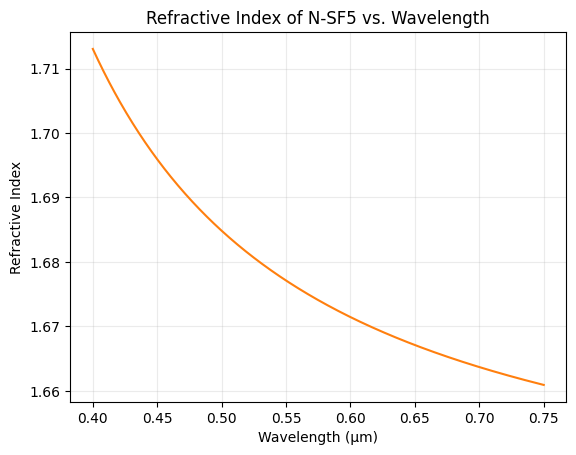

In [4]:
glass = Material("N-SF5")

n_sf5 = glass.n(wavelengths)

plt.plot(wavelengths, n_sf5, "C1")
plt.xlabel("Wavelength (µm)")
plt.ylabel("Refractive Index")
plt.title("Refractive Index of N-SF5 vs. Wavelength")
plt.grid(alpha=0.25)
plt.show()

Note that you may also pass a reference name to the material, which narrows down the material selection if there are multiple matches for the given material name. The reference can include e.g., the glass manufacturer, the author name, year of publication, etc.

In [5]:
glass = Material("N-SF5", reference="Schott")

#### Example 2: Organic material (DNA)

In [6]:
DNA = Material("DNA")

wavelength = 0.26

# call `.item()` to get the value as a scalar
print(f"Refractive Index of DNA at {wavelength} µm: {DNA.n(wavelength).item():.5f}")

Refractive Index of DNA at 0.26 µm: 1.65214


#### Example 3: Others materials (AgCl & toluene)

In [7]:
silver_chloride = Material("AgCl")
toluene = Material("toluene")

wavelength = 0.55

print(
    f"Refractive Index of AgCl at {wavelength} µm: {silver_chloride.n(wavelength).item():.5f}",
)
print(
    f"Refractive Index of toluene at {wavelength} µm: {toluene.n(wavelength).item():.5f}"
)

Refractive Index of AgCl at 0.55 µm: 2.07748
Refractive Index of toluene at 0.55 µm: 1.50006


#### Example 4: Gases (helium)

In [8]:
he = Material("He")

wavelength = 0.612

print(f"Refractive Index of He at {wavelength} µm: {he.n(wavelength).item():.7f}")

Refractive Index of He at 0.612 µm: 1.0000344


## Conclusion

This tutorial covered the three core material types in Optiland:

- **`IdealMaterial`** — fixed refractive index and extinction coefficient; useful for simple,
  constant-parameter simulations.
- **`AbbeMaterial` / `AbbeMaterialE`** — model optical glass from nd and Abbe number; supports
  Buchdahl (recommended) and polynomial dispersion models for d-line and e-line conventions.
- **`Material`** — interface to the 3,200-entry refractiveindex.info database; accepts an optional
  `reference=` hint to disambiguate when multiple entries share the same name.

**Next step:** :doc:`Tutorial_1g_Material_Catalog_and_Registry` dives into the catalog and registry
layer — manufacturer-scoped lookup, `MatchPolicy`, `MaterialCatalog`, `MaterialRegistry`, user
catalogs, and `MaterialSpec` for deterministic surface assignment.


---
## Part 2: Material Catalog And Registry



## 1. Concept: From flat database to structured catalog

Older versions of Optiland performed material lookups by scanning a single flat CSV — fast, but fragile
when the same glass name appeared in multiple manufacturer databases.

The catalog/registry system solves this with three layered components:

| Component | Role |
|---|---|
| `MaterialRegistry` | Process-wide singleton; owns built-in CSV + all user-registered entries |
| `MaterialCatalog` | High-level discovery and search API for a single manufacturer catalog |
| `MatchPolicy` | Enum controlling fuzzy-match behaviour (WARN / BEST / STRICT) |
| `MaterialSpec` | Frozen, hashable parameter bundle for deterministic surface assignment |

In [1]:
from optiland.materials import (
    MaterialCatalog,
    MaterialRegistry,
    MaterialSpec,
    MatchPolicy,
)

## 2. Built-in catalogs

`MaterialCatalog.available()` returns the list of glass manufacturer catalogs bundled with Optiland.
These correspond to the `glass/` group in the refractiveindex.info database.

In [2]:
catalogs = MaterialCatalog.available()
print(f"{len(catalogs)} glass catalogs available:")
print(catalogs)

14 glass catalogs available:
['ami', 'barberini', 'cdgm', 'corning', 'hikari', 'hoya', 'lightpath', 'lzos', 'misc', 'nsg', 'ohara', 'schott', 'sumita', 'vitron']


In [3]:
# List all glasses in the Schott catalog
schott = MaterialCatalog("schott")
schott_glasses = schott.list()
print(f"Schott catalog: {len(schott_glasses)} glasses")
print("First 15:", schott_glasses[:15])

Schott catalog: 171 glasses
First 15: ['AF32ECO', 'B270', 'BAFN6', 'BK7G18', 'BOROFLOAT33', 'D263TECO', 'F2', 'F2G12', 'F2HT', 'F5', 'FK3', 'FK5HTi', 'IRG22', 'IRG23', 'IRG24']


## 3. Looking up a material by name

`MaterialCatalog.get()` returns a `Material` instance ready for use in an optical system.
You can also use `MaterialCatalog.search()` for fuzzy name matching within a catalog.

In [4]:
# Exact lookup
nbk7 = schott.get("N-BK7")
print(nbk7)
print(f"n at 587.6 nm (d-line): {nbk7.n(0.5876).item():.5f}")
print(f"n at 486.1 nm (F-line): {nbk7.n(0.4861).item():.5f}")
print(f"n at 656.3 nm (C-line): {nbk7.n(0.6563).item():.5f}")

Material(name='N-BK7', catalog='schott', λ=[0.30µm, 2.50µm])
n at 587.6 nm (d-line): 1.51680
n at 486.1 nm (F-line): 1.52238
n at 656.3 nm (C-line): 1.51432


In [5]:
# Fuzzy search — returns a ranked list of matching glass names
results = schott.search("bk7", n=5)
print("Search 'bk7' in Schott:", results)

Search 'bk7' in Schott: ['BK7G18', 'N-BK7', 'N-BK7HT', 'N-BK7HTi', 'P-BK7']


## 4. MatchPolicy: controlling catalog search behaviour

`MatchPolicy` controls what happens when the glass name is not an exact match:

| Policy | Behaviour |
|---|---|
| `WARN` (default) | Return best match; emit `OptilandMaterialWarning` |
| `BEST` | Return best match silently |
| `STRICT` | Raise `ValueError` on any non-exact match |

Always use `MatchPolicy.STRICT` in production scripts to catch typos early.

In [6]:
from optiland.materials import Material

# BEST: silent best match
mat_best = Material("N-BK7", catalog="schott", match_policy=MatchPolicy.BEST)
print("BEST  :", mat_best)

# STRICT: exact match only — raises ValueError if not found
mat_strict = Material("N-BK7", catalog="schott", match_policy=MatchPolicy.STRICT)
print("STRICT:", mat_strict)

# STRICT with a typo — will raise ValueError
try:
    bad = Material("N-BK77", catalog="schott", match_policy=MatchPolicy.STRICT)
except ValueError as exc:
    print("Caught expected error:", exc)

BEST  : Material(name='N-BK7', catalog='schott', λ=[0.30µm, 2.50µm])
STRICT: Material(name='N-BK7', catalog='schott', λ=[0.30µm, 2.50µm])
Caught expected error: No matches found for material 'N-BK77' in catalog 'schott'


## 5. Creating a user catalog

Register custom materials for the current session via `MaterialRegistry.instance().register()`.
The data dict follows the refractiveindex.info YAML schema — the simplest form is a tabulated
refractive index table.

In [7]:
# Define a custom glass using Sellmeier-style tabulated data
custom_glass_data = {
    "REFERENCE": "Internal Lab, 2025",
    "DATA": [
        {
            "type": "tabulated n",
            "data": "0.40 1.535\n0.45 1.528\n0.50 1.523\n0.55 1.519\n0.60 1.516\n0.65 1.514\n0.70 1.512\n",
        }
    ],
}

registry = MaterialRegistry.instance()
registry.register("LabCrown-1", "internal", custom_glass_data)

# Retrieve from the custom catalog
lab_glass = MaterialCatalog("internal").get("LabCrown-1", match_policy=MatchPolicy.STRICT)
print(lab_glass)
print(f"n at 550 nm: {lab_glass.n(0.55).item():.4f}")

Material(name='LabCrown-1', catalog='internal', λ=[0.40µm, 0.70µm])
n at 550 nm: 1.5190


**Persistent registration:** Place `.yml` files under `~/.optiland/catalogs/<catalog_name>/`.
They are auto-discovered on the next process start and work with the same API.

## 6. Using catalog materials in a lens system

Surfaces accept a material name string (convenience) or a `Material` instance.
For deterministic, catalog-scoped assignment use `MaterialSpec.to_material()`.

In [8]:
from optiland.optic import Optic

# Resolve materials deterministically via MaterialSpec
mat_crown = MaterialSpec(name="N-BK7", catalog="schott", match_policy=MatchPolicy.STRICT).to_material()
mat_flint = MaterialSpec(name="N-F2", catalog="schott", match_policy=MatchPolicy.STRICT).to_material()

# Build a cemented doublet
doublet = Optic(name="Cemented Doublet")
doublet.surfaces.add(index=0, radius=float("inf"), thickness=float("inf"))
doublet.surfaces.add(index=1, radius=61.5, thickness=6.0, material=mat_crown, is_stop=True)
doublet.surfaces.add(index=2, radius=-44.6, thickness=2.5, material=mat_flint)
doublet.surfaces.add(index=3, radius=-129.0, thickness=0.0)
doublet.surfaces.add(index=4)  # image plane
doublet.set_aperture(aperture_type="EPD", value=25.0)
doublet.fields.set_type("angle")
doublet.fields.add(y=0.0)
doublet.wavelengths.add(value=0.5876, is_primary=True)
doublet.updater.image_solve()

doublet.info()
print(f"\nEFL: {doublet.paraxial.f2():.2f} mm")

╒════╤═════════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │    inf   │     inf     │ Air        │       0 │         12.5    │
│  1 │ Stop - Standard │           │     61.5 │       6     │ N-BK7      │       0 │         12.5    │
│  2 │ Standard        │           │    -44.6 │       2.5   │ N-F2       │       0 │         12.0845 │
│  3 │ Standard        │           │   -129   │      88.912 │ Air        │       0 │         11.9656 │
│  4 │ Planar          │           │    inf   │     nan     │ Air        │       0 │          0      │
╘════╧═════════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════════════╛


EFL: 92.88 mm


## 7. Grouping and filtering

The `glasses_selection()` utility from `optiland.materials.material_utils` returns all glasses
whose dispersion data spans a given wavelength range — ideal for seeding a `GlassExpert` run.
For Abbe number filtering, query the registry DataFrame directly.

In [ ]:
from optiland.materials import glasses_selection, get_nd_vd

# All Schott glasses valid across the visible spectrum
visible_schott = glasses_selection(0.4, 0.7, catalogs=["schott"])
print(f"Schott glasses valid from 400-700 nm: {len(visible_schott)}")
print("Sample:", visible_schott[:8])

Schott glasses valid from 400–700 nm: 161
Sample: ['AF32ECO', 'BAFN6', 'BK7G18', 'BOROFLOAT33', 'D263TECO', 'F2', 'F2G12', 'F2HT']


In [ ]:
# Filter to crown glasses: Vd > 50, nd between 1.45 and 1.70
crown_glasses = [
    g for g in visible_schott
    if (
        (nd_vd := get_nd_vd(g)) != (0, 0)  # skip glasses without SPECS data
        and 1.45 <= nd_vd[0] <= 1.70
        and nd_vd[1] > 50
    )
]
print(f"Crown glasses (nd 1.45-1.70, Vd > 50): {len(crown_glasses)}")
print(crown_glasses[:10])

Crown glasses (nd 1.45–1.70, Vd > 50): 59
['AF32ECO', 'BK7G18', 'D263TECO', 'FK3', 'FK5HTi', 'K10', 'K5G20', 'K7', 'LAK9G15', 'LAKL12']


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Schott Glass Map (crowns highlighted)'}, xlabel='$V_d$', ylabel='$n_d$'>)

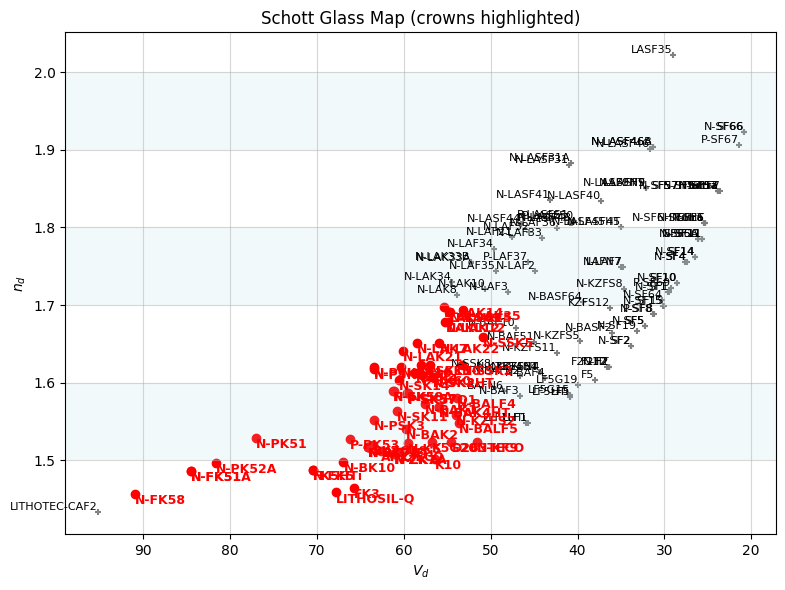

In [11]:
from optiland.materials import plot_glass_map

# Plot the glass map for visible Schott glasses, highlighting the crowns
plot_glass_map(visible_schott, highlights=crown_glasses, title="Schott Glass Map (crowns highlighted)")

## Conclusion

In this tutorial you learned how to:

- Use `MaterialCatalog.available()` to discover bundled glass catalogs
- Look up and fuzzy-search glasses within a manufacturer catalog
- Control match behaviour with `MatchPolicy.WARN / BEST / STRICT`
- Register custom materials programmatically via `MaterialRegistry`
- Assign catalog materials to surfaces using `MaterialSpec` for deterministic, typo-safe design
- Filter glasses by wavelength range and nd/Vd using `glasses_selection` and `get_nd_vd`

The next step is **Tutorial 5c** (Glass Expert optimization) which uses these same catalog tools
to solve the categorical glass selection problem automatically.